# Introduction

This is a short tutorial on how to use CogStat for diffusion model parameter recovery.

The main reason for using the CogStat package for diffusion analysis is the same as using CogStat in general: The analysis is automatic, and the most important results are displayed in a more understandable and compact way. Therefore, in the GUI version, less clicking is needed for a comprehensive result, and in the code version, fewer lines are needed.

More information about how CogStat runs diffusion analysis can be found at https://doc.cogstat.org/Behavioral-data-diffusion-analysis.


# Step 0. Preparation

We import the required packages.

In [1]:
# Step 0. Import the necessary packages and use appropriate settings

%matplotlib inline
import os
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from cogstat import cogstat as cs
print('CogStat version:', cs.__version__)

/home/attila/Programs/cogstat_venv_py312_new/lib/python3.12/site-packages/rpy2/rinterface.py:1189: UserWarning: Environment variable "PWD" redefined by R and overriding existing variable.
  warnings.warn(


CogStat version: 2.6dev


# Step 1. Load the data

In [2]:
# Step 1. Load the data

# We use one of the CogStat demo data sets for this demonstration
# Technically, first, we find the path of the demo data, then use os.path.join() to have a valid path in all OSes
cs_dir, dummy_filename = os.path.split(cs.__file__)
data = cs.CogStatData(data = os.path.join(cs_dir, 'demo_data/diffusion model', 'number_comparison.xls'))
# Check what we have loaded
cs.display(data.print_data(brief=True))

,participant ID,notation,number_left,number_right,response,RT,ratio,correct response,correct
Type,str,str,num,num,str,num,num,num,num
Level,nom,nom,unk,unk,nom,unk,unk,unk,unk
,a,arabic,1,5,p,1.067252,0.8,0,1
,a,arabic,4,5,p,0.827141,0.2,0,1
,a,arabic,1,9,p,0.585145,0.888889,0,1
,a,arabic,6,8,p,0.828295,0.25,0,1
,a,arabic,4,5,p,0.603906,0.2,0,1
,a,arabic,3,5,p,0.562921,0.4,0,1
,a,arabic,5,4,q,0.625,0.2,0,1
,a,arabic,3,5,p,0.531489,0.4,0,1


# Step 2. Recover the parameters

The recovery is only a single statement in the code.

In [3]:
# Step 2. Recover the parameters

# Run the analysis.
results = data.diffusion(error_name='correct', RT_name='RT', participant_name='participant ID', 
                         condition_names=['notation', 'ratio'], 
                         correct_coding='1', reaction_time_in='sec', scaling_parameter=0.1)
# Display the results. We'll also use the results for the additional calculations below.
cs.display(results)

## Access the results

The result is displayed above as text. To use the results for further calculations, you may use the results that is an ordered dictionary, and some of the items are the tables themselves. Technically, the tables are pandas Stylers. This is how you can use them:

In [4]:
print('The keys of the results dictionary:')
for key in results.keys():
    print(key)

# The tables including the recovered parameters are pandas Stylers:
display(results['drift rate'])
display(type(results['drift rate']))

# If you want to access the pandas DataFrame, use the data attribute of the Stylers:
display(results['drift rate'].data)
display(type(results['drift rate'].data))

The keys of the results dictionary:
analysis info
N
drift rate
threshold
nondecision time


pandas.io.formats.style.Styler

notation          arabic                                                    \
ratio           0.111111  0.125000  0.142857  0.166667  0.200000  0.222222   
participant ID                                                               
a               0.347369  0.290364  0.306586  0.353789  0.176380  0.364767   
arita           0.151665  0.242331  0.108205  0.122422  0.130637  0.094581   
d               0.354268  0.294950  0.175560  0.235972  0.347710  0.331706   
f               0.212896  0.194592  0.183025  0.289065  0.261567  0.221415   
g               0.156223  0.198623  0.019654  0.186296  0.288639  0.233291   
h               0.289049  0.194815  0.231107  0.322848  0.334677  0.285320   
j               0.235905  0.255848  0.161441  0.281751  0.330513  0.224812   
jazmin          0.271417  0.303928  0.174601  0.327141  0.251399  0.331142   
jn              0.103890  0.082660  0.209224  0.142065  0.126314  0.177488   
k               0.153474  0.174822  0.263164  0.246544  0.189077  0.164070   
kutya           0.053621  0.147231  0.024234  0.296663  0.275687  0.254330   
kyuss           0.280728  0.207733  0.249147  0.229589  0.245609  0.261229   
l               0.376347  0.281817  0.354809  0.366652  0.263041  0.317525   
lapat           0.233859  0.251741  0.193792  0.300724  0.190529  0.220194   
m               0.205561  0.194397  0.085140  0.255464  0.171729  0.268968   
n               0.291574  0.316071  0.249490  0.380177  0.253593  0.294135   
o               0.256689  0.201993  0.109480  0.154102  0.211582  0.170453   
p               0.250573  0.201578  0.172451  0.275774  0.187211  0.148686   
q               0.325339  0.244626  0.200428  0.253196  0.169701  0.233063   
r               0.216601  0.211646  0.276825  0.234730  0.283054  0.340108   
s               0.221905  0.266869  0.281878  0.330781  0.257125  0.313680   
szendvics       0.272999  0.270635  0.192264  0.298662  0.218480  0.222098   
t               0.329366  0.195059  0.191229  0.281300  0.288698  0.192181   

notation                                                ...      dots  \
ratio           0.250000  0.285714  0.333333  0.375000  ...  0.625000   
participant ID                                          ...             
a               0.285727  0.204363  0.387313  0.307303  ...  0.354416   
arita           0.199009  0.112118  0.215948  0.204821  ...  0.220528   
d               0.237116  0.338604  0.382228  0.264678  ...  0.221248   
f               0.261291  0.175374  0.244210  0.268407  ...  0.235184   
g               0.158698  0.163226  0.250879  0.254488  ...  0.200803   
h               0.265421  0.281454  0.351174  0.324116  ...  0.281016   
j               0.309363  0.232840  0.325159  0.449332  ...  0.285382   
jazmin          0.392480  0.266410  0.332610  0.302485  ...  0.393196   
jn              0.152844  0.293386  0.234128  0.100159  ...  0.285542   
k               0.238819  0.212415  0.207021  0.167798  ...  0.275628   
kutya           0.369916  0.162786  0.312757  0.335294  ...  0.435036   
kyuss           0.271753  0.275135  0.277246  0.226471  ...  0.325583   
l               0.456013  0.417926  0.482923  0.342514  ...  0.227643   
lapat           0.245234  0.237439  0.252346  0.201559  ...  0.206719   
m               0.218117  0.233550  0.220262  0.243574  ...  0.172230   
n               0.255465  0.251062  0.389673  0.301072  ...  0.244918   
o               0.167972  0.209886  0.214987  0.250947  ...  0.302033   
p               0.230997  0.224548  0.308092  0.348574  ...  0.309720   
q               0.260491  0.234853  0.290301  0.239001  ...  0.204091   
r               0.289689  0.206465  0.379581  0.312531  ...  0.367867   
s               0.332787  0.120557  0.357980  0.231419  ...  0.350146   
szendvics       0.272331  0.333407  0.289069  0.236330  ...  0.340819   
t               0.307304  0.341780  0.350323  0.351039  ...  0.285808   

notation                                                                

pandas.DataFrame

# Step 3. Run additional analyses on the recovered parameters

Then, you can use the parameter recovery results for further calculations similar to any other pandas DataFrame.

In the example below, the calculations show a characteristic difference between dot comparison and Arabic number comparison: while dot comparison becomes impossible to solve when the ratio closes 0 (as predicted by the psychophysical model of nuber comparison), this does not apply for Arabic numbers (in contrast with the widely accepted psychophysical model).

In [5]:
# Display the drift rates as a function of ratio (x-axis) and notation (colors)
drift_rate_result = results['drift rate'].data.mean().reset_index()
drift_rate_result.columns = ['notation', 'ratio', 'drift rate']
fig, ax = plt.subplots(figsize=(8,6))
drift_rate_result['notation'] = drift_rate_result['notation'].astype('category')
drift_rate_result.plot(x='ratio', y ='drift rate', kind='scatter', c='notation', cmap='viridis', ax=ax)

<Axes: xlabel='ratio', ylabel='drift rate'>

Importantly, this characteristic difference is not straightforward neither in error rates nor in reaction times, as shown below. This is one main reason, why diffusion model parameter recovery can be fundamental.

In [6]:
# Display the error rates as a function of ratio (x-axis) and notation (colors)
pivot_correct_mean = data.data_frame.pivot_table(values='correct',
    index='participant ID', columns=['notation', 'ratio'], aggfunc='mean', dropna=False)
error_rate_result = pivot_correct_mean.mean().reset_index()
error_rate_result.columns = ['notation', 'ratio', 'error rate']
fig, ax = plt.subplots(figsize=(8,6))
error_rate_result['notation'] = error_rate_result['notation'].astype('category')
error_rate_result.plot(x='ratio', y ='error rate', kind='scatter', c='notation', cmap='viridis', ax=ax)

# Display the reaction times as a function of ratio (x-axis) and notation (colors)
pivot_RT_median = data.data_frame.pivot_table(values='RT',
    index='participant ID', columns=['notation', 'ratio'], aggfunc='median', dropna=False)
reaction_time_result = pivot_RT_median.mean().reset_index()
reaction_time_result.columns = ['notation', 'ratio', 'reaction time']
fig, ax = plt.subplots(figsize=(8,6))
reaction_time_result['notation'] = reaction_time_result['notation'].astype('category')
reaction_time_result.plot(x='ratio', y ='reaction time', kind='scatter', c='notation', cmap='viridis', ax=ax)

<Axes: xlabel='ratio', ylabel='reaction time'>

Or you can use CogStat for further analysis, to save more coding/typing.

notation,participant ID,arabic,dots
Type,str,num,num
Level,nom,int,int
,a,0.340857,0.248183
,arita,0.224422,0.170005
,d,0.321185,0.219349
,f,0.247539,0.182101
,g,0.279285,0.209919
,h,0.356592,0.218291
,j,0.379693,0.259981
,jazmin,0.367317,0.285512


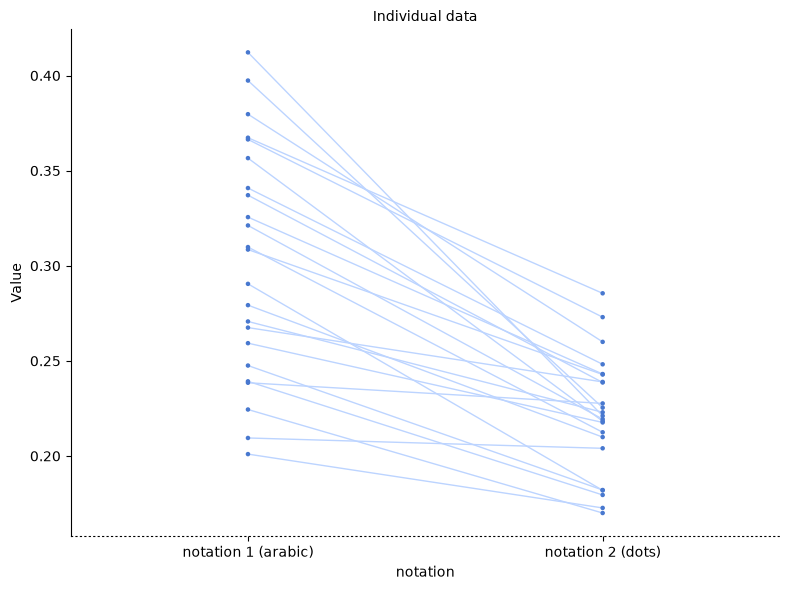

,arabic,dots
Mean,0.302174606638613,0.221525177185285
Standard deviation,0.060002056251872,0.030203311597404
Maximum,0.412186862292242,0.285512488727478
Upper quartile,0.348724143672013,0.240877188371519
Median,0.308511296140394,0.221093137487330
Lower quartile,0.253419283512188,0.206973996502440
Minimum,0.200979931509590,0.170005415491294


,Value
Cohen's d,1.661
Eta-squared,0.408


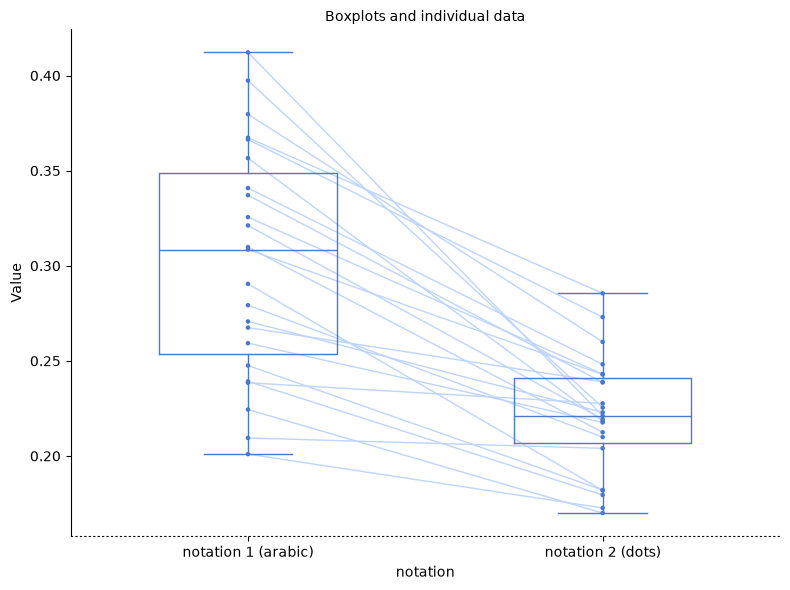

,,Point estimation,95% CI (low),95% CI (high)
notation,(Original variable name),,,
notation 1,arabic,0.302174606638613,0.275644624041866,0.328704589235359
notation 2,dots,0.221525177185285,0.208170746002467,0.234879608368104


,Point estimation,95% CI (low),95% CI (high)
Hedges' g,1.632,0.972,2.292


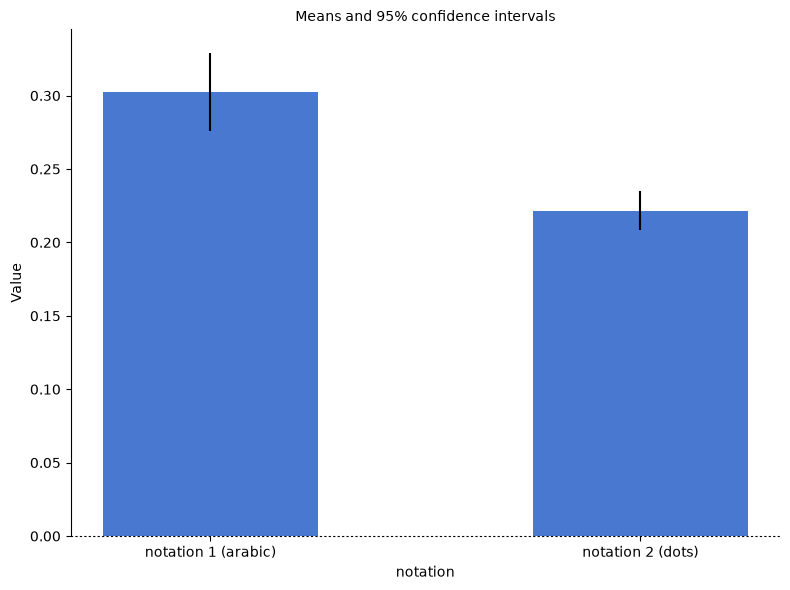

In [7]:
# For example, make a CogStat data object from the mean drift rate of the participants for the two notations.
CS_data_error_rates = cs.CogStatData(data = results['drift rate'].data.stack(level=0).mean(axis=1).unstack().reset_index(),
                                     measurement_levels=['nom', 'int', 'int'])
cs.display(CS_data_error_rates.print_data())

# Then compare the mean error rate for the two notations
cs.display(CS_data_error_rates.compare_variables(var_names=['arabic', 'dots'], factors=[['notation', 2]]))